# Analises Avancadas da Rede Telefonica de Campinas

Este notebook reune metricas estruturais classicas de redes complexas, usadas para caracterizar o
**tipo** de rede que emerge das chamadas:

1. **Lei de potencia (rede livre de escala?)** - a distribuicao de grau segue uma lei de potencia?
2. **Assortatividade e nucleo-periferia (k-core)** - hubs se conectam com hubs? Existe um nucleo coeso?
3. **Small-world** - a rede combina alto agrupamento local com caminhos curtos?
4. **Robustez** - como a rede se fragmenta sob ataques dirigidos vs. falhas aleatorias?

Como os outros notebooks, ele roda de forma independente: o **setup** abaixo reconstroi o grafo a
partir de `edges_antenna.parquet`.

## Setup - reconstrucao do grafo a partir do parquet

Reconstroi a rede nao-direcionada ponderada e a componente gigante `G_main`. Os `self-loops`
(usuarios que ligam para o proprio id) sao removidos, pois algumas metricas estruturais (k-core)
nao os admitem; sao apenas 18 arestas, sem efeito relevante.

In [ ]:
from pathlib import Path
import sys
from config import CITY_NAME
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

DATA_DIR = Path('./dados')
edges = pd.read_parquet(DATA_DIR / 'edges_antenna.parquet')

ep = edges.copy()
ep["source"] = np.minimum(ep["id_emisor"].astype(str), ep["id_receiver"].astype(str))
ep["target"] = np.maximum(ep["id_emisor"].astype(str), ep["id_receiver"].astype(str))
edges_graph = (
    ep.groupby(["source", "target"], as_index=False)
    .agg(q_calls=("q_calls", "sum"), calls_duration_total=("calls_duration_total", "sum"))
)
edges_graph["weight"] = np.log1p(edges_graph["q_calls"]) * np.log1p(edges_graph["calls_duration_total"])

G = nx.from_pandas_edgelist(edges_graph, "source", "target", edge_attr=["weight", "q_calls"])
G_main = G.subgraph(max(nx.connected_components(G), key=len)).copy()
G_main.remove_edges_from(list(nx.selfloop_edges(G_main)))

degree = np.array([d for _, d in G_main.degree()])
print(f"Componente gigante: {G_main.number_of_nodes():,} nos / {G_main.number_of_edges():,} arestas")
print(f"Grau: medio {degree.mean():.2f} | mediana {np.median(degree):.0f} | max {degree.max()}")

## 1. Lei de potencia (rede livre de escala?)

Redes livres de escala tem distribuicao de grau \(P(k) \sim k^{-\alpha}\): muitos nos com poucas
conexoes e poucos hubs muito conectados. Ajustamos a cauda da distribuicao por **maxima
verossimilhanca** (metodo de Clauset), escolhendo o `x_min` que minimiza a distancia de
Kolmogorov-Smirnov entre a distribuicao empirica e o ajuste.

In [2]:
def fit_powerlaw_discrete(x):
    """Ajuste MLE de lei de potencia discreta com varredura de x_min (metodo de Clauset)."""
    x = np.asarray(x)
    x = x[x > 0]
    best = None
    for xmin in range(1, int(x.max())):
        tail = x[x >= xmin]
        if len(tail) < 30:
            break
        alpha = 1 + len(tail) / np.sum(np.log(tail / (xmin - 0.5)))
        xs = np.sort(tail)
        cdf_emp = np.arange(1, len(xs) + 1) / len(xs)
        cdf_fit = 1 - (xs / xmin) ** (-(alpha - 1))
        ks = np.max(np.abs(cdf_emp - cdf_fit))
        if best is None or ks < best["ks"]:
            best = {"xmin": xmin, "alpha": alpha, "n_tail": int(len(tail)), "ks": ks}
    return best

pl = fit_powerlaw_discrete(degree)
print(f"Expoente estimado alpha = {pl['alpha']:.2f}")
print(f"x_min (inicio da cauda) = {pl['xmin']}  (nos na cauda: {pl['n_tail']})")
print(f"Distancia KS do ajuste  = {pl['ks']:.3f}")

Expoente estimado alpha = 3.57
x_min (inicio da cauda) = 20  (nos na cauda: 36)
Distancia KS do ajuste  = 0.118


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


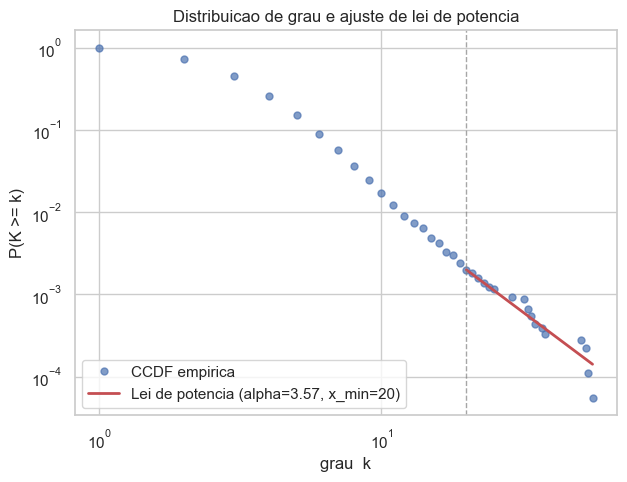

In [3]:
# CCDF empirica e a lei de potencia ajustada
x = np.sort(np.unique(degree))
ccdf = np.array([np.mean(degree >= k) for k in x])

xmin, alpha = pl["xmin"], pl["alpha"]
xx = x[x >= xmin]
ccdf_at_xmin = np.mean(degree >= xmin)
yy = ccdf_at_xmin * (xx / xmin) ** (-(alpha - 1))

plt.figure(figsize=(7, 5))
plt.loglog(x, ccdf, "o", ms=5, alpha=0.7, label="CCDF empirica")
plt.loglog(xx, yy, "r-", lw=2, label=f"Lei de potencia (alpha={alpha:.2f}, x_min={xmin})")
plt.axvline(xmin, color="gray", ls="--", lw=1, alpha=0.7)
plt.xlabel("grau  k")
plt.ylabel("P(K >= k)")
plt.title("Distribuicao de grau e ajuste de lei de potencia")
plt.legend()
plt.show()

A distribuicao de grau e claramente de **cauda pesada**: a maior parte dos usuarios tem poucas
conexoes e existe um pequeno conjunto de hubs. O expoente estimado (alpha entre 3 e 4) esta na faixa
tipica de redes sociais. A distancia KS moderada indica que uma lei de potencia *pura* nao descreve
perfeitamente toda a distribuicao - comportamento comum em redes de comunicacao reais, onde a cauda
costuma ser bem aproximada por uma lei de potencia, mas o corpo da distribuicao pode ser melhor
descrito por uma lognormal.

## 2. Assortatividade e estrutura nucleo-periferia (k-core)

A **assortatividade de grau** mede se nos de grau alto tendem a se conectar com nos de grau alto
(r > 0, assortativa) ou com nos de grau baixo (r < 0, disassortativa). A **decomposicao em k-core**
identifica nucleos cada vez mais densos: o k-core e o maior subgrafo em que todo no tem pelo menos
grau k.

Coeficiente de assortatividade de grau: r = 0.398


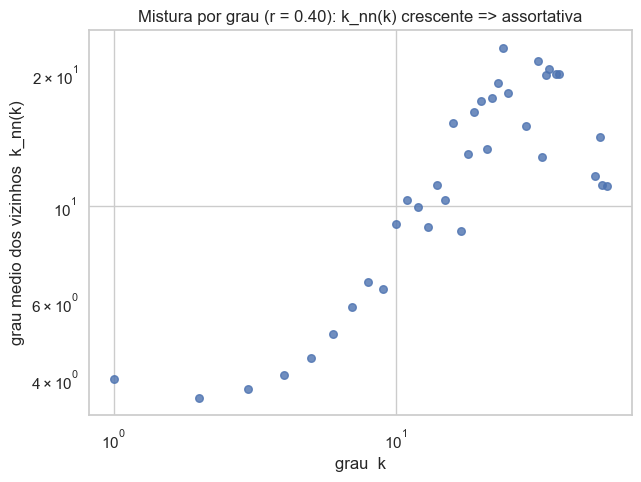

In [4]:
assort = nx.degree_assortativity_coefficient(G_main)
print(f"Coeficiente de assortatividade de grau: r = {assort:.3f}")

# k_nn(k): grau medio dos vizinhos em funcao do grau
knn = nx.average_degree_connectivity(G_main)
ks_knn = sorted(knn)
plt.figure(figsize=(7, 5))
plt.scatter(ks_knn, [knn[k] for k in ks_knn], s=30, alpha=0.8)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("grau  k")
plt.ylabel("grau medio dos vizinhos  k_nn(k)")
plt.title(f"Mistura por grau (r = {assort:.2f}): k_nn(k) crescente => assortativa")
plt.show()

k-core maximo: 12
Nucleo (k = 12): 29 nos


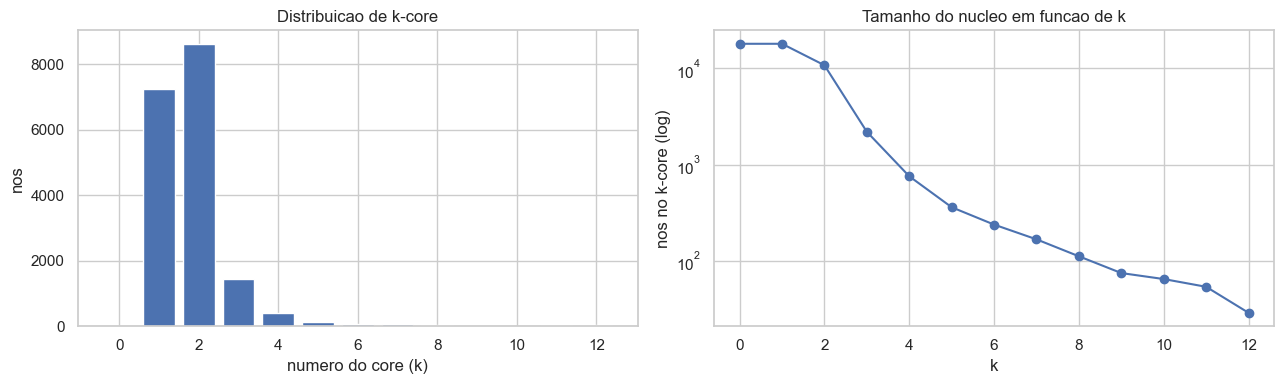

In [5]:
core = pd.Series(nx.core_number(G_main))
kmax = int(core.max())
print(f"k-core maximo: {kmax}")
print(f"Nucleo (k = {kmax}): {(core == kmax).sum()} nos")

ks_core = list(range(0, kmax + 1))
core_sizes = [(core >= k).sum() for k in ks_core]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(core, bins=range(0, kmax + 2), align="left", rwidth=0.8)
axes[0].set_xlabel("numero do core (k)")
axes[0].set_ylabel("nos")
axes[0].set_title("Distribuicao de k-core")

axes[1].plot(ks_core, core_sizes, "o-")
axes[1].set_yscale("log")
axes[1].set_xlabel("k")
axes[1].set_ylabel("nos no k-core (log)")
axes[1].set_title("Tamanho do nucleo em funcao de k")
plt.tight_layout()
plt.show()

A rede e **assortativa** (r > 0): hubs tendem a se comunicar com outros usuarios bem conectados,
e a curva k_nn(k) cresce com o grau. Isso e tipico de redes sociais (ao contrario de muitas redes
tecnologicas, que sao disassortativas). A decomposicao em k-core mostra uma periferia grande de nos
de core baixo e um **nucleo coeso pequeno** (o k-core maximo concentra poucas dezenas de usuarios
densamente conectados).

## 3. Small-world

Uma rede e *small-world* quando combina **alto agrupamento local** (clustering) com **caminhos
curtos** (caminho minimo medio L pequeno), comparada a uma rede aleatoria equivalente. Usamos o
coeficiente de Humphries: \(\sigma = (C/C_{rand}) / (L/L_{rand})\); \(\sigma \gg 1\) indica
small-world. O caminho medio e estimado por amostragem de nos-fonte (a rede e grande demais para o
calculo exato).

In [6]:
def avg_shortest_path_sampled(Gx, n_samples=500, seed=42):
    rng = random.Random(seed)
    nodes = list(Gx.nodes())
    total = count = 0
    for s in rng.sample(nodes, min(n_samples, len(nodes))):
        lengths = nx.single_source_shortest_path_length(Gx, s)
        total += sum(lengths.values())
        count += len(lengths) - 1
    return total / count

C_real = nx.average_clustering(G_main)
L_real = avg_shortest_path_sampled(G_main)

# rede aleatoria equivalente (Erdos-Renyi com mesmo n e m)
n, m = G_main.number_of_nodes(), G_main.number_of_edges()
G_rand = nx.gnm_random_graph(n, m, seed=42)
G_rand = G_rand.subgraph(max(nx.connected_components(G_rand), key=len)).copy()
C_rand = nx.average_clustering(G_rand)
L_rand = avg_shortest_path_sampled(G_rand)

sigma = (C_real / C_rand) / (L_real / L_rand)

resumo_sw = pd.DataFrame({
    "metrica": ["Clustering medio (C)", "Caminho minimo medio (L)"],
    "rede real": [C_real, L_real],
    "aleatoria (ER)": [C_rand, L_rand],
})
print(resumo_sw.to_string(index=False))
print(f"\nsigma = (C/C_rand) / (L/L_rand) = {sigma:.1f}   (sigma >> 1 => small-world)")

                 metrica  rede real  aleatoria (ER)
    Clustering medio (C)   0.163690        0.000207
Caminho minimo medio (L)  12.090472        9.097792

sigma = (C/C_rand) / (L/L_rand) = 595.6   (sigma >> 1 => small-world)


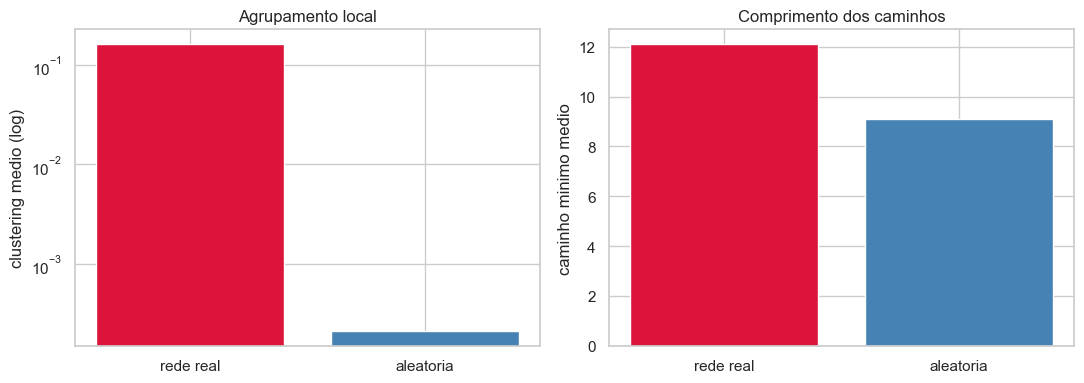

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["rede real", "aleatoria"], [C_real, C_rand], color=["crimson", "steelblue"])
axes[0].set_yscale("log")
axes[0].set_ylabel("clustering medio (log)")
axes[0].set_title("Agrupamento local")

axes[1].bar(["rede real", "aleatoria"], [L_real, L_rand], color=["crimson", "steelblue"])
axes[1].set_ylabel("caminho minimo medio")
axes[1].set_title("Comprimento dos caminhos")
plt.tight_layout()
plt.show()

O agrupamento local da rede real e **centenas de vezes maior** do que o de uma rede aleatoria de
mesmo tamanho, enquanto o caminho minimo medio fica na mesma ordem de grandeza (apenas um pouco
maior, refletindo a forte estrutura de comunidades). O coeficiente \(\sigma \gg 1\) confirma o
carater **small-world**: grupos locais muito coesos conectados por poucos passos atraves de hubs e
pontes.

## 4. Robustez: tolerancia a falhas vs. ataques

Removendo nos progressivamente, acompanhamos o tamanho da componente gigante. Comparamos duas
estrategias: **ataque dirigido** (remove primeiro os nos de maior grau) e **falha aleatoria**
(remove nos ao acaso). Redes com hubs costumam ser robustas a falhas, mas frageis a ataques.

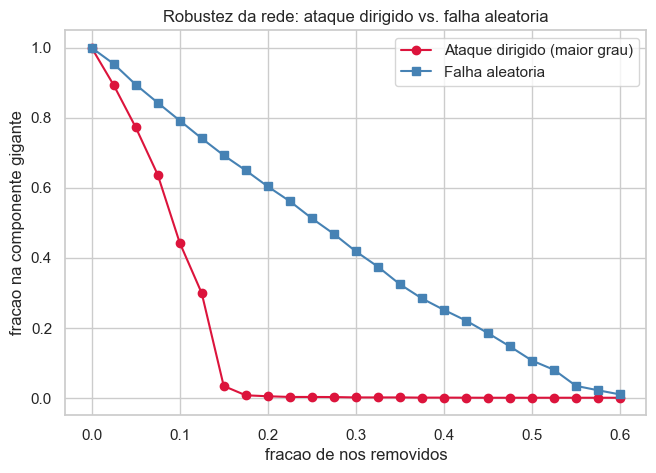

In [8]:
def giant_fraction_curve(Gx, removal_order, max_frac=0.6, steps=25):
    N = Gx.number_of_nodes()
    all_nodes = set(Gx.nodes())
    fracs = np.linspace(0, max_frac, steps)
    out = []
    for f in fracs:
        k = int(f * N)
        H = Gx.subgraph(all_nodes - set(removal_order[:k]))
        gc = max((len(c) for c in nx.connected_components(H)), default=0)
        out.append(gc / N)
    return fracs, out

deg_order = [u for u, _ in sorted(G_main.degree(), key=lambda kv: -kv[1])]   # ataque
rand_order = list(G_main.nodes())
random.Random(1).shuffle(rand_order)                                         # falha

fr, y_attack = giant_fraction_curve(G_main, deg_order)
_, y_random = giant_fraction_curve(G_main, rand_order)

plt.figure(figsize=(7.5, 5))
plt.plot(fr, y_attack, "o-", color="crimson", label="Ataque dirigido (maior grau)")
plt.plot(fr, y_random, "s-", color="steelblue", label="Falha aleatoria")
plt.xlabel("fracao de nos removidos")
plt.ylabel("fracao na componente gigante")
plt.title("Robustez da rede: ataque dirigido vs. falha aleatoria")
plt.legend()
plt.show()

A diferenca entre as curvas e a **assinatura classica de uma rede com hubs**: sob falhas
aleatorias a componente gigante encolhe devagar (a maioria dos nos removidos e periferica), mas sob
ataque dirigido aos hubs a rede se **fragmenta rapidamente** - poucos pontos percentuais de remocao
dos nos de maior grau ja desconectam grande parte da rede. Isso reforca o papel critico dos hubs
identificados pelas centralidades.

## Sintese

| Propriedade | Resultado | Leitura |
|---|---|---|
| Distribuicao de grau | cauda pesada, alpha ~ 3-4 | poucos hubs, muitos nos pouco conectados |
| Assortatividade | r > 0 | hubs ligam com hubs (tipico de rede social) |
| k-core | nucleo pequeno e coeso | periferia grande + nucleo denso |
| Small-world | sigma >> 1 | alto clustering com caminhos curtos |
| Robustez | fragil a ataque, robusta a falha | hubs sao criticos |

Em conjunto, essas metricas caracterizam a rede telefonica de Campinas como uma **rede social de
cauda pesada, modular e small-world**, organizada em torno de hubs cuja remocao compromete a
conectividade global.